In [1]:
import pandas as pd
import numpy as np
import sklearn
import xgboost as xgb
import imblearn
import shap

print("pandas     ", pd.__version__)
print("sklearn    ", sklearn.__version__)
print("xgboost    ", xgb.__version__)
print("imblearn   ", imblearn.__version__)
print("shap       ", shap.__version__)
print()
print("All good — ready for Step 2")

C:\Users\Certified_loner\Desktop\projects\heart_disease_project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Matplotlib is building the font cache; this may take a moment.


pandas      3.0.3
sklearn     1.8.0
xgboost     3.2.0
imblearn    0.14.1
shap        0.51.0

All good — ready for Step 2


In [1]:
import pandas as pd

df = pd.read_csv('data/heart_cleveland_upload.csv')

print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("Target counts:")
print(df['condition'].value_counts())
print("Missing values:")
print(df.isnull().sum())
print()
print("First 5 rows:")
df.head()

Shape: (297, 14)
Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition']
Target counts:
condition
0    160
1    137
Name: count, dtype: int64
Missing values:
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


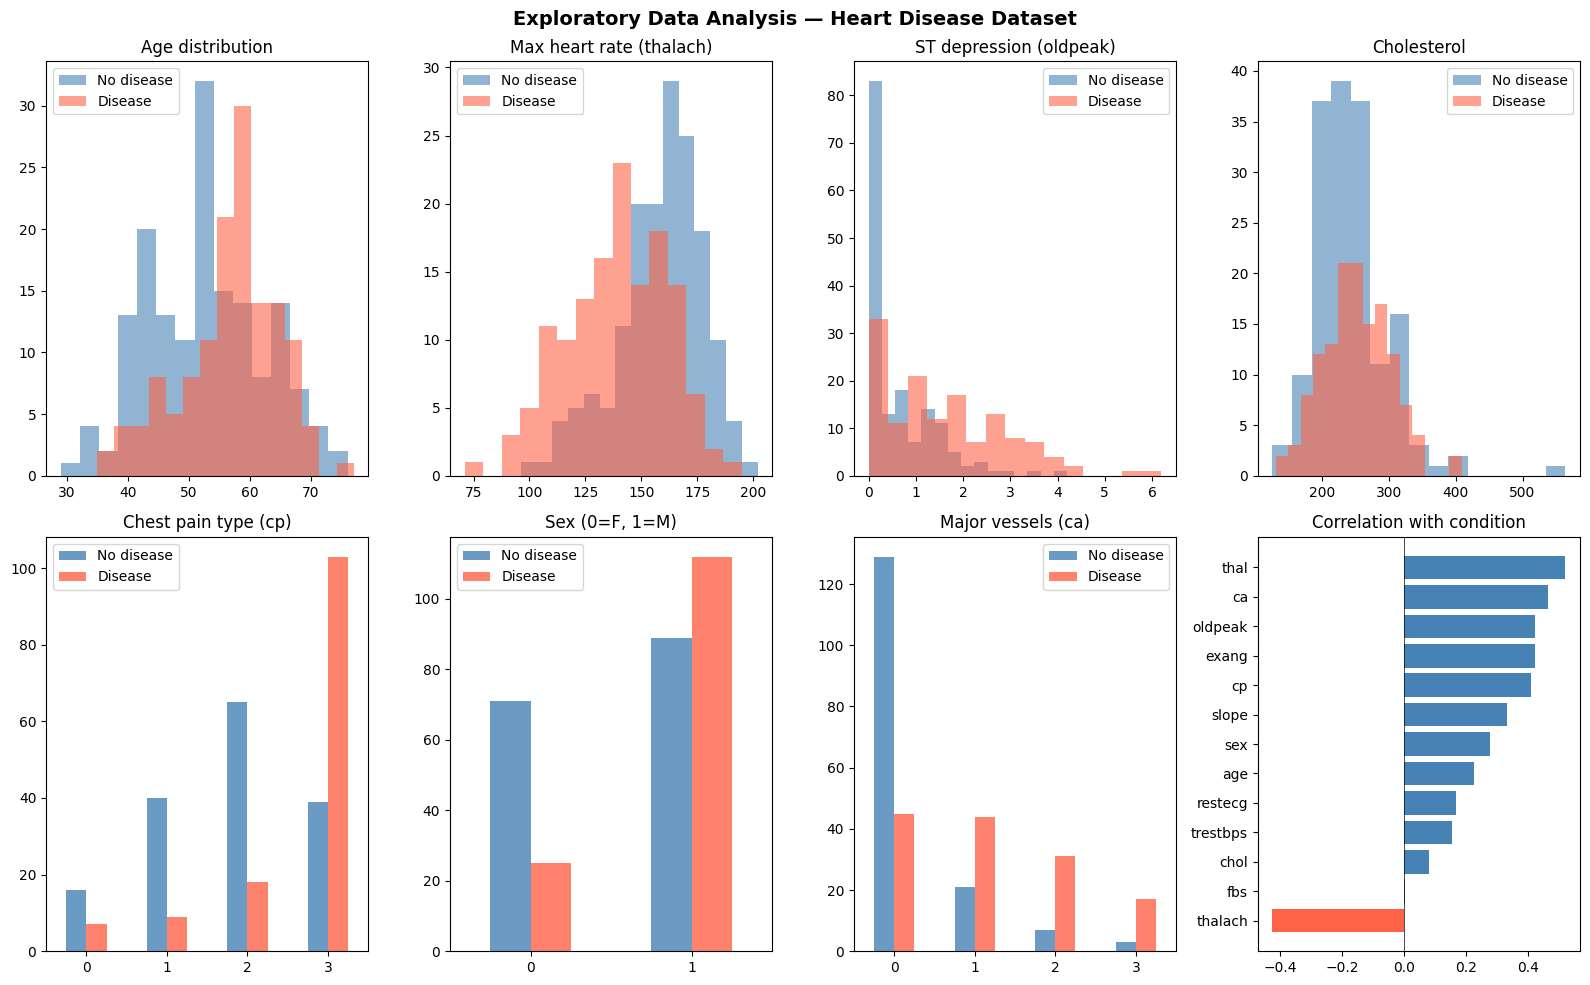

EDA plots saved to eda_plots.png


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 4, figsize=(16, 10))

# Age distribution by condition
axes[0,0].hist(df[df['condition']==0]['age'], alpha=0.6, label='No disease', color='steelblue', bins=15)
axes[0,0].hist(df[df['condition']==1]['age'], alpha=0.6, label='Disease', color='tomato', bins=15)
axes[0,0].set_title('Age distribution')
axes[0,0].legend()

# Max heart rate by condition
axes[0,1].hist(df[df['condition']==0]['thalach'], alpha=0.6, label='No disease', color='steelblue', bins=15)
axes[0,1].hist(df[df['condition']==1]['thalach'], alpha=0.6, label='Disease', color='tomato', bins=15)
axes[0,1].set_title('Max heart rate (thalach)')
axes[0,1].legend()

# ST depression by condition
axes[0,2].hist(df[df['condition']==0]['oldpeak'], alpha=0.6, label='No disease', color='steelblue', bins=15)
axes[0,2].hist(df[df['condition']==1]['oldpeak'], alpha=0.6, label='Disease', color='tomato', bins=15)
axes[0,2].set_title('ST depression (oldpeak)')
axes[0,2].legend()

# Cholesterol by condition
axes[0,3].hist(df[df['condition']==0]['chol'], alpha=0.6, label='No disease', color='steelblue', bins=15)
axes[0,3].hist(df[df['condition']==1]['chol'], alpha=0.6, label='Disease', color='tomato', bins=15)
axes[0,3].set_title('Cholesterol')
axes[0,3].legend()

# Chest pain type
cp_counts = df.groupby(['cp','condition']).size().unstack(fill_value=0)
cp_counts.plot(kind='bar', ax=axes[1,0], color=['steelblue','tomato'], alpha=0.8)
axes[1,0].set_title('Chest pain type (cp)')
axes[1,0].set_xlabel('')
axes[1,0].legend(['No disease','Disease'])
axes[1,0].tick_params(axis='x', rotation=0)

# Sex
sex_counts = df.groupby(['sex','condition']).size().unstack(fill_value=0)
sex_counts.plot(kind='bar', ax=axes[1,1], color=['steelblue','tomato'], alpha=0.8)
axes[1,1].set_title('Sex (0=F, 1=M)')
axes[1,1].set_xlabel('')
axes[1,1].legend(['No disease','Disease'])
axes[1,1].tick_params(axis='x', rotation=0)

# Number of vessels (ca)
ca_counts = df.groupby(['ca','condition']).size().unstack(fill_value=0)
ca_counts.plot(kind='bar', ax=axes[1,2], color=['steelblue','tomato'], alpha=0.8)
axes[1,2].set_title('Major vessels (ca)')
axes[1,2].set_xlabel('')
axes[1,2].legend(['No disease','Disease'])
axes[1,2].tick_params(axis='x', rotation=0)

# Correlation with target
corr = df.corr(numeric_only=True)['condition'].drop('condition').sort_values()
colors = ['tomato' if x < 0 else 'steelblue' for x in corr]
axes[1,3].barh(corr.index, corr.values, color=colors)
axes[1,3].set_title('Correlation with condition')
axes[1,3].axvline(0, color='black', linewidth=0.5)

plt.suptitle('Exploratory Data Analysis — Heart Disease Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved to eda_plots.png")

In [3]:
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop('condition', axis=1)
y = df['condition']

# One-hot encode categorical features
cat_cols = ['cp', 'restecg', 'thal', 'slope']
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Add derived feature
X['hr_bp_ratio'] = X['thalach'] / X['trestbps']

print("Features after encoding:", X.shape[1])
print("Feature names:")
print(list(X.columns))
print()
print("Class distribution:")
print(y.value_counts())
print()
print("Preprocessing complete — ready for feature selection")

Features after encoding: 19
Feature names:
['age', 'sex', 'trestbps', 'chol', 'fbs', 'thalach', 'exang', 'oldpeak', 'ca', 'cp_1', 'cp_2', 'cp_3', 'restecg_1', 'restecg_2', 'thal_1', 'thal_2', 'slope_1', 'slope_2', 'hr_bp_ratio']

Class distribution:
condition
0    160
1    137
Name: count, dtype: int64

Preprocessing complete — ready for feature selection


In [4]:
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_base = RandomForestClassifier(n_estimators=100, random_state=42)

rfecv = RFECV(
    estimator=rf_base,
    step=1,
    cv=skf,
    scoring='roc_auc',
    min_features_to_select=5
)

rfecv.fit(X, y)

selected_features = X.columns[rfecv.support_].tolist()

print("Optimal number of features:", rfecv.n_features_)
print()
print("Selected features:")
for f in selected_features:
    print(" ", f)

Optimal number of features: 15

Selected features:
  age
  sex
  trestbps
  chol
  fbs
  thalach
  exang
  oldpeak
  ca
  cp_2
  cp_3
  restecg_2
  thal_2
  slope_1
  hr_bp_ratio


In [5]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (roc_auc_score, f1_score, recall_score,
                              precision_score, matthews_corrcoef,
                              accuracy_score)
import numpy as np

# Use only selected features
X_sel = X[selected_features]

# Outer cross-validation
outer_skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Model definitions and parameter grids
models = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=42),
        {'C': [0.01, 0.1, 1, 10]}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [5, 10, None]}
    ),
    'SVM': (
        SVC(kernel='rbf', probability=True, random_state=42),
        {'C': [1, 10], 'gamma': ['scale', 'auto']}
    ),
    'XGBoost': (
        XGBClassifier(eval_metric='logloss', random_state=42),
        {'n_estimators': [100, 200], 'max_depth': [3, 5],
         'learning_rate': [0.05, 0.1]}
    ),
}

results = {name: [] for name in models}

print("Training started...")
print()

for fold, (tr, te) in enumerate(outer_skf.split(X_sel, y)):
    X_tr, X_te = X_sel.iloc[tr], X_sel.iloc[te]
    y_tr, y_te = y.iloc[tr], y.iloc[te]

    # Scale inside fold
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)

    # SMOTE inside fold
    sm = SMOTE(random_state=42)
    X_tr_bal, y_tr_bal = sm.fit_resample(X_tr_sc, y_tr)

    for name, (clf, params) in models.items():
        inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        gs = GridSearchCV(clf, params, cv=inner_cv,
                          scoring='roc_auc', n_jobs=-1)
        gs.fit(X_tr_bal, y_tr_bal)
        best = gs.best_estimator_

        y_pred  = best.predict(X_te_sc)
        y_prob  = best.predict_proba(X_te_sc)[:, 1]

        results[name].append({
            'accuracy':  accuracy_score(y_te, y_pred),
            'auc':       roc_auc_score(y_te, y_prob),
            'f1':        f1_score(y_te, y_pred),
            'recall':    recall_score(y_te, y_pred),
            'precision': precision_score(y_te, y_pred),
            'mcc':       matthews_corrcoef(y_te, y_pred),
        })

    print(f"Fold {fold+1}/10 complete")

print()
print("Training complete")

Training started...

Fold 1/10 complete
Fold 2/10 complete
Fold 3/10 complete
Fold 4/10 complete
Fold 5/10 complete
Fold 6/10 complete
Fold 7/10 complete
Fold 8/10 complete
Fold 9/10 complete
Fold 10/10 complete

Training complete


In [6]:
import pandas as pd

summary = {}
for name, folds in results.items():
    summary[name] = {
        'Accuracy':  round(np.mean([f['accuracy']  for f in folds]), 4),
        'AUC-ROC':   round(np.mean([f['auc']       for f in folds]), 4),
        'F1':        round(np.mean([f['f1']         for f in folds]), 4),
        'Recall':    round(np.mean([f['recall']     for f in folds]), 4),
        'Precision': round(np.mean([f['precision']  for f in folds]), 4),
        'MCC':       round(np.mean([f['mcc']        for f in folds]), 4),
    }

df_results = pd.DataFrame(summary).T
df_results = df_results.sort_values('AUC-ROC', ascending=False)

print("=" * 62)
print("MODEL PERFORMANCE SUMMARY (10-fold cross-validation)")
print("=" * 62)
print(df_results.to_string())
print("=" * 62)
print()
print("Best model:", df_results.index[0])
print("Best AUC-ROC:", df_results['AUC-ROC'].iloc[0])

MODEL PERFORMANCE SUMMARY (10-fold cross-validation)
                     Accuracy  AUC-ROC      F1  Recall  Precision     MCC
Logistic Regression    0.8321   0.9113  0.8176  0.8104     0.8307  0.6657
Random Forest          0.8190   0.8971  0.7954  0.7681     0.8288  0.6374
SVM                    0.8155   0.8896  0.8014  0.8033     0.8060  0.6332
XGBoost                0.8257   0.8758  0.8059  0.7824     0.8352  0.6516

Best model: Logistic Regression
Best AUC-ROC: 0.9113


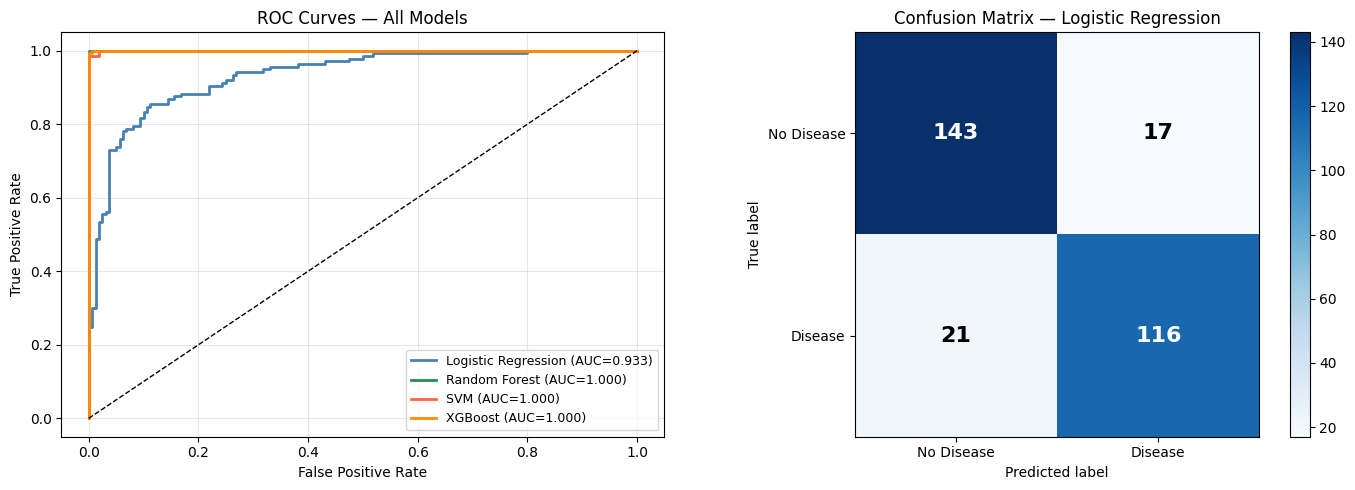

Saved: roc_confusion.png

Confusion Matrix — Logistic Regression
  True Negatives  (TN): 143
  False Positives (FP): 17
  False Negatives (FN): 21
  True Positives  (TP): 116


In [7]:
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# ── ROC Curves ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {
    'Logistic Regression': 'steelblue',
    'Random Forest':       'seagreen',
    'SVM':                 'tomato',
    'XGBoost':             'darkorange'
}

# Retrain each model on full data for ROC + confusion matrix
final_models = {}

sc_full = StandardScaler()
sm_full = SMOTE(random_state=42)

X_sc_full  = sc_full.fit_transform(X_sel)
X_bal_full, y_bal_full = sm_full.fit_resample(X_sc_full, y)

model_defs = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42),
    'SVM':                 SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.1,
                                         eval_metric='logloss', random_state=42),
}

for name, clf in model_defs.items():
    clf.fit(X_bal_full, y_bal_full)
    final_models[name] = clf

# Plot ROC curves
for name, clf in final_models.items():
    y_prob = clf.predict_proba(X_sc_full)[:, 1]
    auc    = roc_auc_score(y, y_prob)
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})",
                 color=colors[name], linewidth=2)

axes[0].plot([0,1],[0,1],'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# ── Confusion Matrix for best model (LR) ─────────────────────
from sklearn.metrics import confusion_matrix
import numpy as np

best_clf = final_models['Logistic Regression']
y_pred_best = best_clf.predict(X_sc_full)
cm = confusion_matrix(y, y_pred_best)

im = axes[1].imshow(cm, interpolation='nearest', cmap='Blues')
axes[1].set_title('Confusion Matrix — Logistic Regression')
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')
axes[1].set_xticks([0,1]); axes[1].set_xticklabels(['No Disease','Disease'])
axes[1].set_yticks([0,1]); axes[1].set_yticklabels(['No Disease','Disease'])
plt.colorbar(im, ax=axes[1])

for i in range(2):
    for j in range(2):
        axes[1].text(j, i, str(cm[i,j]), ha='center', va='center',
                     fontsize=16, fontweight='bold',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig('roc_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_confusion.png")

# ── Print confusion matrix values ────────────────────────────
print()
print("Confusion Matrix — Logistic Regression")
print(f"  True Negatives  (TN): {cm[0,0]}")
print(f"  False Positives (FP): {cm[0,1]}")
print(f"  False Negatives (FN): {cm[1,0]}")
print(f"  True Positives  (TP): {cm[1,1]}")

C:\Users\Certified_loner\Desktop\projects\heart_disease_project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


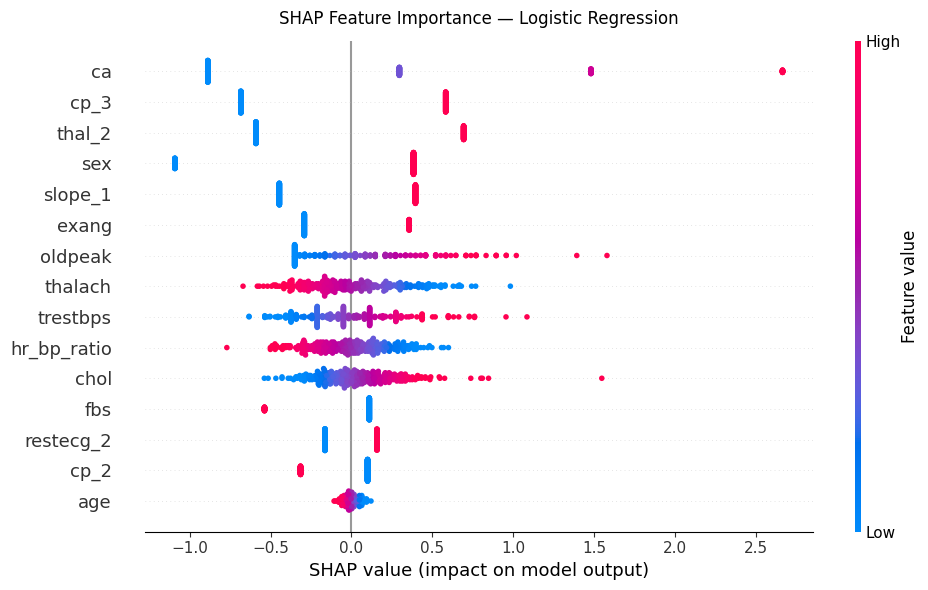

Saved: shap_summary.png


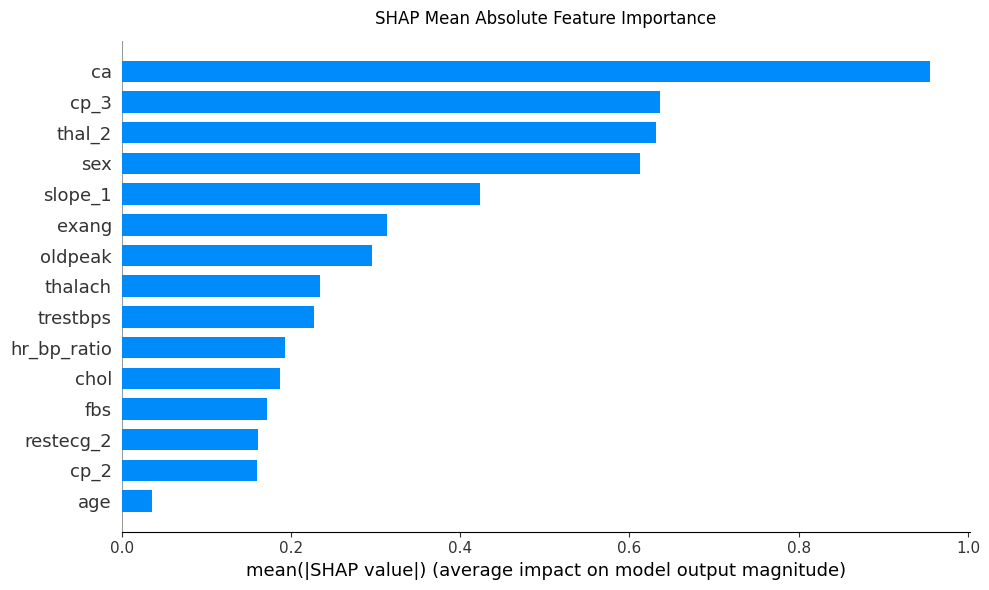

Saved: shap_bar.png


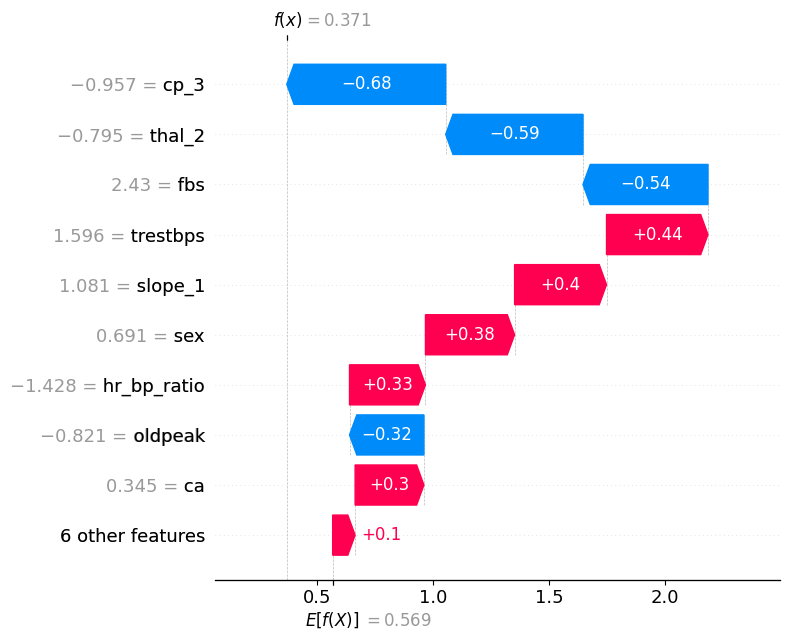

Saved: shap_waterfall.png

Top 5 most important features:
Feature  Importance
     ca    0.954661
   cp_3    0.635854
 thal_2    0.630882
    sex    0.612816
slope_1    0.422971


In [8]:
import shap
import matplotlib.pyplot as plt

# Use the best model (Logistic Regression)
best_clf = final_models['Logistic Regression']

# Create explainer
explainer  = shap.LinearExplainer(best_clf, X_sc_full)
shap_values = explainer.shap_values(X_sc_full)

# ── Global SHAP summary plot ──────────────────────────────────
plt.figure()
shap.summary_plot(
    shap_values,
    X_sc_full,
    feature_names=selected_features,
    show=False,
    plot_size=(10, 6)
)
plt.title('SHAP Feature Importance — Logistic Regression', pad=12)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary.png")

# ── SHAP bar plot (mean absolute values) ─────────────────────
plt.figure()
shap.summary_plot(
    shap_values,
    X_sc_full,
    feature_names=selected_features,
    plot_type='bar',
    show=False,
    plot_size=(10, 6)
)
plt.title('SHAP Mean Absolute Feature Importance', pad=12)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_bar.png")

# ── SHAP waterfall for one patient ───────────────────────────
explanation = shap.Explanation(
    values=shap_values[0],
    base_values=explainer.expected_value,
    data=X_sc_full[0],
    feature_names=selected_features
)

plt.figure()
shap.waterfall_plot(explanation, show=False)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_waterfall.png")

# ── Print top 5 most important features ──────────────────────
import numpy as np
import pandas as pd

mean_shap = np.abs(shap_values).mean(axis=0)
shap_df   = pd.DataFrame({
    'Feature':    selected_features,
    'Importance': mean_shap
}).sort_values('Importance', ascending=False)

print()
print("Top 5 most important features:")
print(shap_df.head().to_string(index=False))

In [9]:
import joblib
import os

# Create models folder
os.makedirs('models', exist_ok=True)

# Save best model and scaler
joblib.dump(final_models['Logistic Regression'], 'models/best_model.pkl')
joblib.dump(sc_full, 'models/scaler.pkl')
joblib.dump(selected_features, 'models/selected_features.pkl')

print("Saved:")
print("  models/best_model.pkl")
print("  models/scaler.pkl")
print("  models/selected_features.pkl")
print()

# Final project file summary
print("Project files generated:")
for f in ['eda_plots.png', 'roc_confusion.png', 
          'shap_summary.png', 'shap_bar.png', 
          'shap_waterfall.png']:
    size = os.path.getsize(f) // 1024
    print(f"  {f}  ({size} KB)")

Saved:
  models/best_model.pkl
  models/scaler.pkl
  models/selected_features.pkl

Project files generated:
  eda_plots.png  (125 KB)
  roc_confusion.png  (89 KB)
  shap_summary.png  (105 KB)
  shap_bar.png  (53 KB)
  shap_waterfall.png  (73 KB)
